**Equipe:**
*   **Vinícius Paula Ribeiro** - RA: 12723131464
*   **Kevin Christian Teixeira** Heidorn - RA: 12723127838
*   **Zheng poi King** - RA: 12723117754
*   **Robson Gabriel** - RA: 1272313956
*   **Vitor Ferreira Leal** - RA: 12726131780

**Links:**
*   [Github](https://github.com/ViniciusPaula140/Analise-de-chocolate)
*   [Documentação](https://analise-de-pascoa-unifacs-cc-202.gitbook.io/analise-de-pascoa-cc-unifacs-2026.1)
*   [Dashboard - Visualização](https://unifacspascoa.streamlit.app)













# **1 - ETAPA DE EXTRAÇÃO**

In [ ]:

import yfinance as yf
import pandas as pd
import requests

# MAPEAMENTO DE ATIVOS GLOBAIS (A Cadeia de Suprimentos do Chocolate)

ativos_financeiros = {
    "Cacau": "CC=F",      # Matéria-prima principal do produto
    "Acucar": "SB=F",     # Complemento direto
    "Leite": "DC=F",      # Derivados lácteos
    "Soja": "ZS=F",       # Representa Lecitina e óleos (Gordura vegetal)
    "Milho": "ZC=F",      # Representa Xaropes e adoçantes
    "Trigo": "ZW=F",      # Representa Wafer e Biscoitos (ex: Bis, KitKat)
    "Petroleo": "BZ=F"    # Proxy estratégico: Representa custo de Plástico (embalagem) e Diesel (Frete)
}
print("Iniciando a Extração de Insumos e Logística...")


# CONSUMO DA API DO YAHOO FINANCE (Mercado Internacional)
# Baixa apenas a coluna de fechamento ('Close') de todos os ativos no período definido
dados_commodities = yf.download(list(ativos_financeiros.values()), start="2023-01-01", end="2026-12-31")['Close']

# Esta linha complexa substitui os códigos confusos (ex: CC=F) pelos nomes reais (ex: Cacau)
dados_commodities.columns = [list(ativos_financeiros.keys())[list(ativos_financeiros.values()).index(col)] for col in dados_commodities.columns]

# Ajuste de Índice: Transforma a data, que era o índice da tabela, em uma coluna normal
dados_commodities = dados_commodities.reset_index().rename(columns={'Date': 'Data'})
dados_commodities['Data'] = pd.to_datetime(dados_commodities['Data'])

# PADRONIZAÇÃO TEMPORAL (resample 'ME'): A bolsa varia todo dia.
# Aqui tiramos a MÉDIA do mês inteiro para poder cruzar com a inflação (que é mensal).
base_insumos_mensal = dados_commodities.resample('ME', on='Data').mean().reset_index()


# CONSUMO DA API DO BANCO CENTRAL DO BRASIL (SGS)
# Códigos oficias das séries temporais no BCB:
# 10813 = Cotação do Dólar | 432 = Taxa Selic (Custo do Crédito) | 1635 = IPCA Alimentos (Nossa variável Alvo)
series_bcb = {"Dolar": 10813, "Selic": 432, "Inflacao_Alimentos": 1635}
base_macro_mensal = pd.DataFrame()

print("Capturando Câmbio, Juros e Inflação do Banco Central...")

# Loop que varre nosso dicionário e faz a requisição GET na API do Governo
for nome, codigo in series_bcb.items():
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2026"

    # Converte o retorno JSON direto para uma tabela Pandas
    df = pd.DataFrame(requests.get(url).json())

    # Tipagem de Dados (Cast): Garante que datas sejam Datas e valores sejam Numéricos
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['valor'] = pd.to_numeric(df['valor'])
    df.columns = ['Data', nome]

    # Igual ao Yahoo: Agrupa por média mensal para compatibilizar as bases
    df_m = df.resample('ME', on='Data').mean().reset_index()

    # Lógica de Merge: Vai "colando" as colunas (Dólar, Selic, IPCA) lado a lado pela Data
    if base_macro_mensal.empty:
        base_macro_mensal = df_m
    else:
        base_macro_mensal = pd.merge(base_macro_mensal, df_m, on='Data', how='inner')


# EXPORTAÇÃO (Data Lake Simulado)
print("\n Fase 1 Concluída: Bases de Insumos e Macro geradas.")

# Salva o resultado bruto em CSV para não precisar fazer requisições na API toda vez que rodar
base_insumos_mensal.to_csv("base_insumos_mensal.csv", index=False)
base_macro_mensal.to_csv("base_macro_mensal.csv", index=False)

Iniciando a Extração de Insumos e Logística...


/tmp/ipykernel_4795/2791852868.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_commodities = yf.download(list(ativos_financeiros.values()), start="2023-01-01", end="2026-12-31")['Close']
[*********************100%***********************]  7 of 7 completed


Capturando Câmbio, Juros e Inflação do Banco Central...

 Fase 1 Concluída: Bases de Insumos e Macro geradas.


# **2 - UNIFICAÇÃO INSUMOS X CUSTO**

In [ ]:

!pip install openpyxl -q

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CARREGAMENTO DOS CHECKPOINTS
insumos = pd.read_csv("base_insumos_mensal.csv")
macro = pd.read_csv("base_macro_mensal.csv")

# UNIFICAÇÃO E TRATAMENTO DE BURACOS DA API
df_unificado = pd.merge(insumos, macro, on='Data', how='inner')

# CORREÇÃO CRÍTICA: Ativos com baixa liquidez (Leite, Trigo) podem vir com buracos do Yahoo.
# O .ffill() copia o preço do mês anterior para tapar esse buraco e salvar a linha
df_unificado = df_unificado.ffill().bfill()


# ENGENHARIA DE DADOS: A MÁQUINA DO TEMPO EM TODAS AS COMMODITIES
colunas_para_atrasar = ['Cacau', 'Acucar', 'Leite', 'Soja', 'Milho', 'Trigo', 'Petroleo', 'Dolar']

for col in colunas_para_atrasar:
    df_unificado[f'{col}_6M_Atras'] = df_unificado[col].shift(6)
    df_unificado[f'{col}_12M_Atras'] = df_unificado[col].shift(12)

# LIMPEZA DIRECIONADA (TARGETED DROPNA) - O QUE SALVA O MODELO
# Pandas para deletar APENAS os 12 primeiros meses gerados pelo shift do nosso motor principal.
colunas_vitais_para_a_ia = ['Cacau_12M_Atras', 'Dolar_12M_Atras', 'Petroleo_12M_Atras', 'Acucar_12M_Atras']

df_final = df_unificado.dropna(subset=colunas_vitais_para_a_ia).reset_index(drop=True)

# Formatação essencial para o Excel/Power BI
df_final['Data'] = pd.to_datetime(df_final['Data']).dt.date

# EXPORTAÇÃO DO DATASET FINAL (Dataset final -> Direto para Excel)
df_final.to_excel("dataset_projeto_pascoa.xlsx", index=False)

print("Fase 2 Concluída: O erro de 'Vazamento de Nulos' foi corrigido e o Excel gerado!")
print(f"Total de linhas salvas para a IA estudar: {len(df_final)} meses.")

Fase 2 Concluída: O erro de 'Vazamento de Nulos' foi corrigido e o Excel gerado!
Total de linhas salvas para a IA estudar: 28 meses.


#**3 - MAPA DE CORRELAÇÃO**


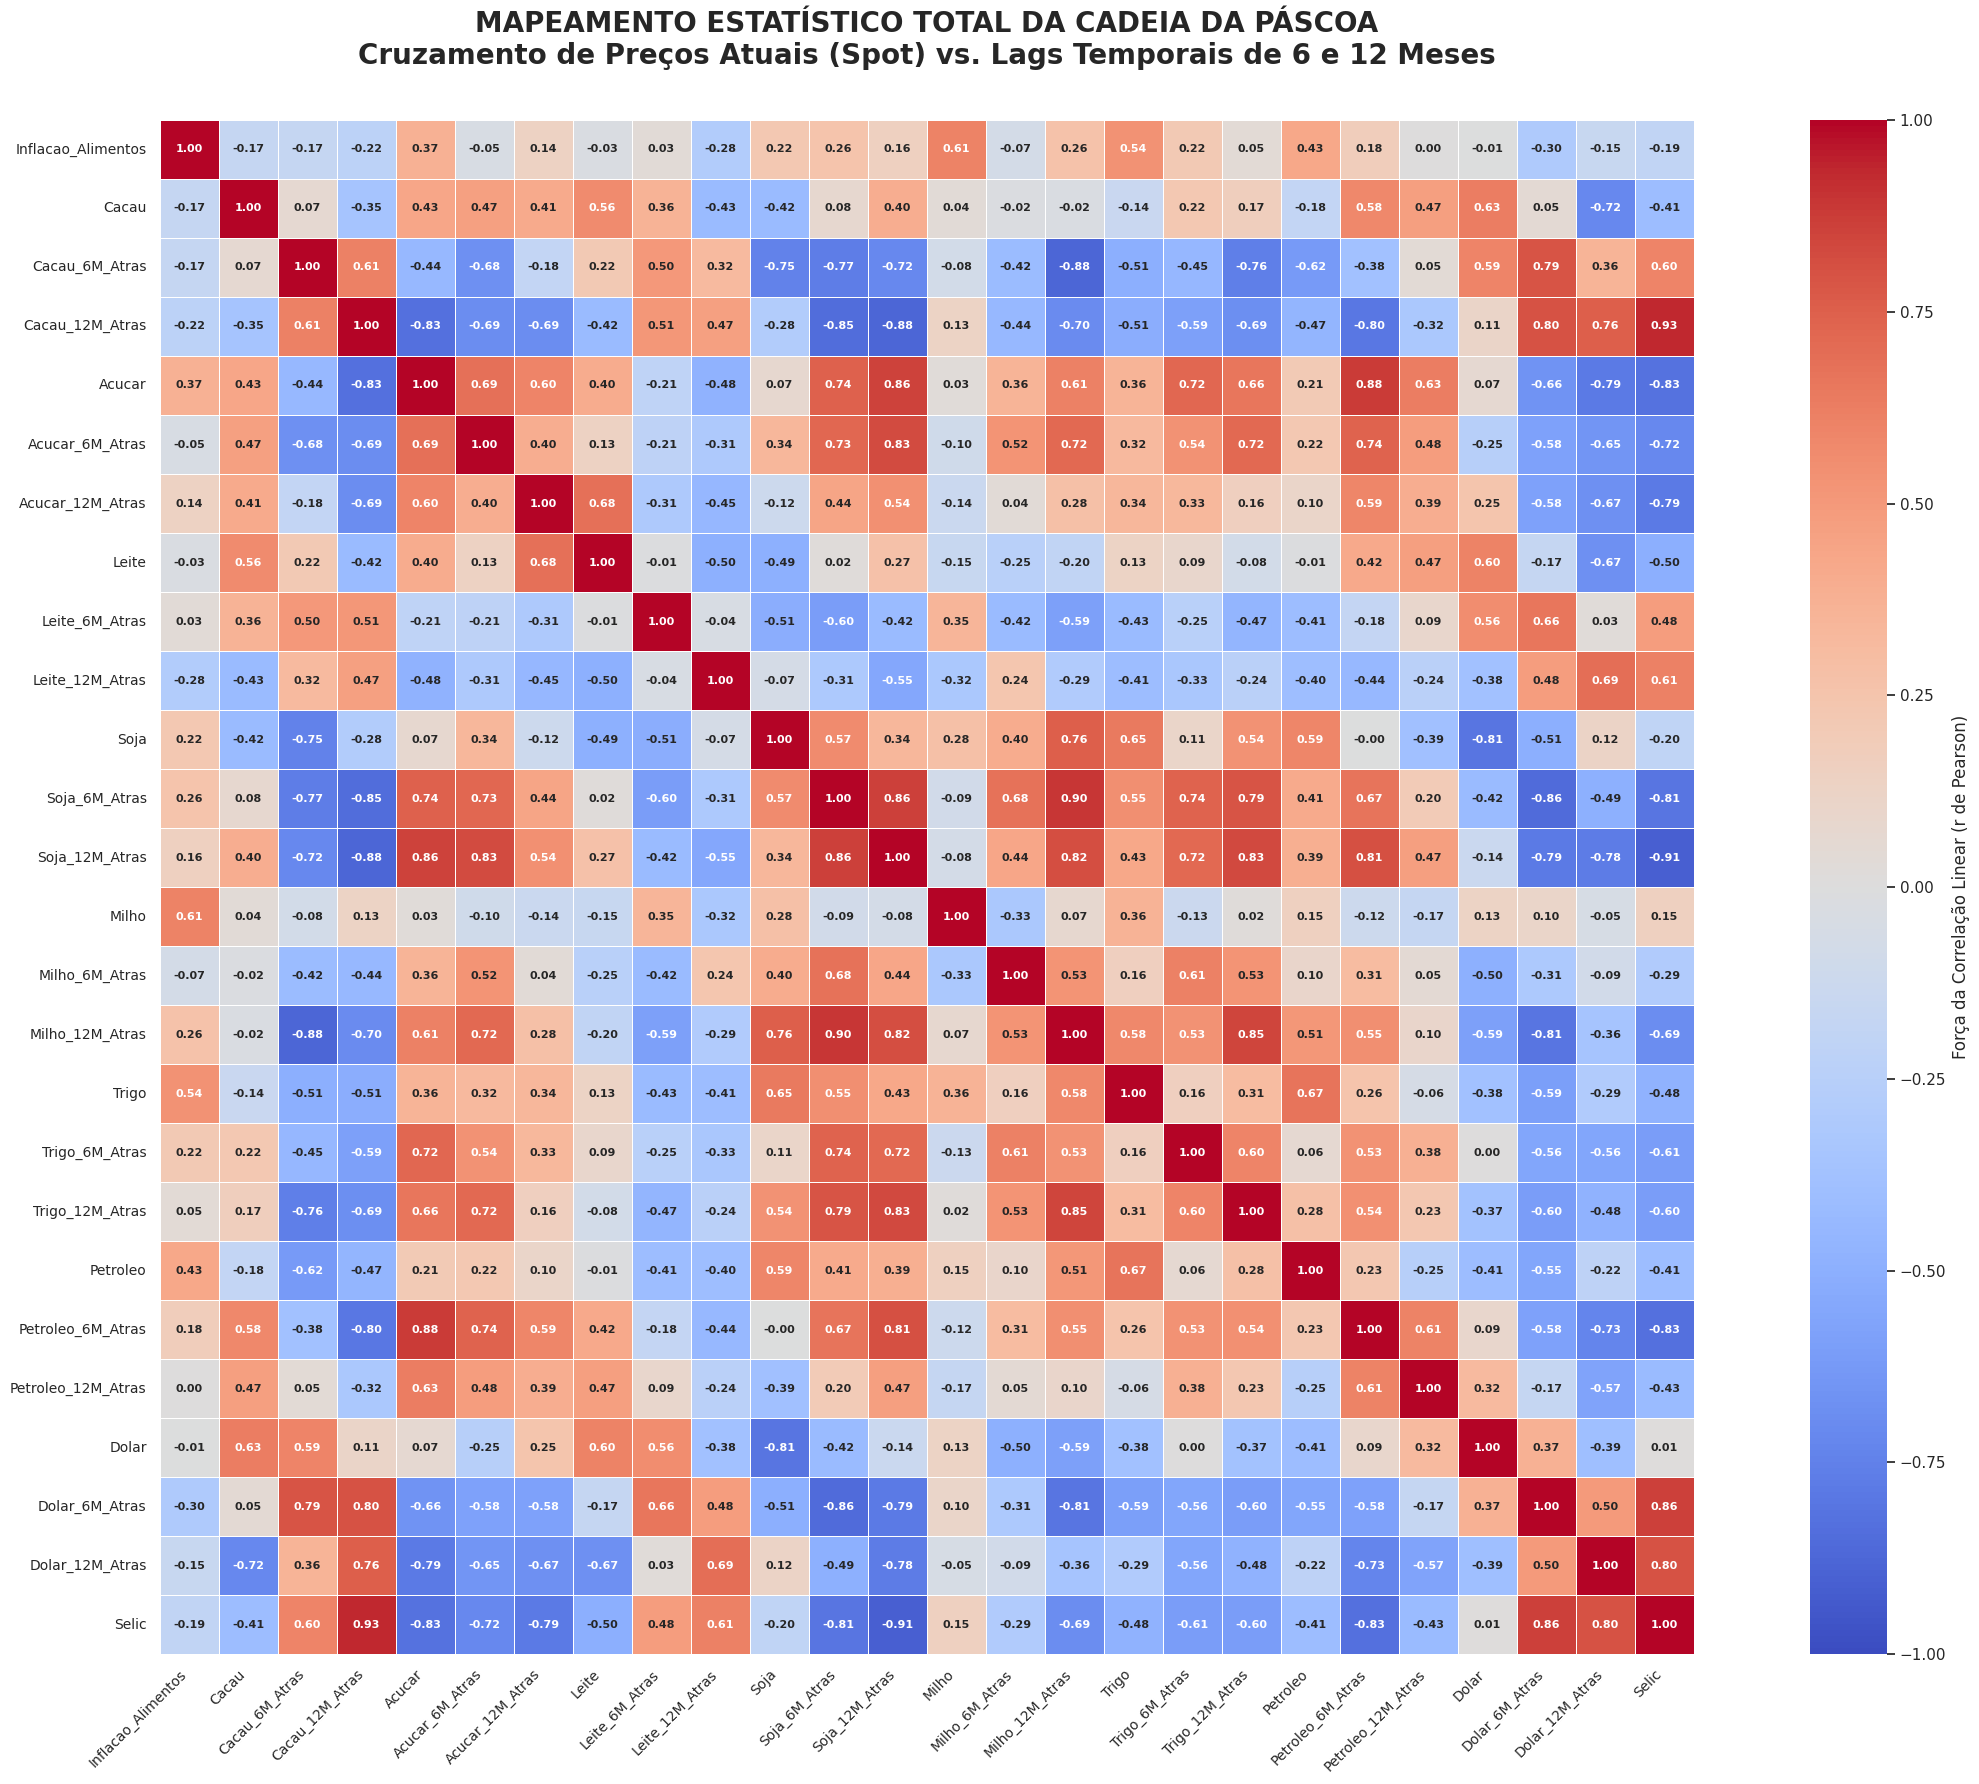


🔍 RESUMO DAS MAIORES CORRELAÇÕES COM A INFLAÇÃO (VETORES DE CUSTO):
--------------------------------------------------
Milho              0.605406
Trigo              0.537201
Petroleo           0.426472
Acucar             0.371324
Dolar_6M_Atras     0.303500
Leite_12M_Atras    0.282282
Milho_12M_Atras    0.258917
Soja_6M_Atras      0.257241
Soja               0.222955
Cacau_12M_Atras    0.219646
Name: Inflacao_Alimentos, dtype: float64

🔍 DIAGNÓSTICO DE MULTICOLINEARIDADE E EFEITO SUBSTITUIÇÃO:
--------------------------------------------------
MAIORES CONEXÕES POSITIVAS (Insumos que encarecem em bloco):
• Cacau_12M_Atras    <-> Selic              :  93.37%
• Soja_6M_Atras      <-> Milho_12M_Atras    :  89.73%
• Acucar             <-> Petroleo_6M_Atras  :  88.26%
• Soja_6M_Atras      <-> Soja_12M_Atras     :  86.43%
• Dolar_6M_Atras     <-> Selic              :  86.35%

MAIORES CONEXÕES NEGATIVAS (Efeito de Substituição de Mercado):
• Cacau_12M_Atras    <-> Soja_6M_Atras      : -85.11

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# INGESTÃO DE DADOS
# Carregamento do dataset previamente limpo e tratado.
df = pd.read_excel("dataset_projeto_pascoa.xlsx")

# DEFINIÇÃO DO ESPAÇO DE VARIÁVEIS (FEATURES ATUAIS + LAGS TEMPORAIS)
colunas_analise = [
    'Inflacao_Alimentos',
    'Cacau', 'Cacau_6M_Atras', 'Cacau_12M_Atras',
    'Acucar', 'Acucar_6M_Atras', 'Acucar_12M_Atras',
    'Leite', 'Leite_6M_Atras', 'Leite_12M_Atras',
    'Soja', 'Soja_6M_Atras', 'Soja_12M_Atras',
    'Milho', 'Milho_6M_Atras', 'Milho_12M_Atras',
    'Trigo', 'Trigo_6M_Atras', 'Trigo_12M_Atras',
    'Petroleo', 'Petroleo_6M_Atras', 'Petroleo_12M_Atras',
    'Dolar', 'Dolar_6M_Atras', 'Dolar_12M_Atras', 'Selic'
]

# Cálculo da Matriz de Correlação Linear utilizando o Coeficiente de Pearson (r).
df_corr = df[colunas_analise].dropna().corr(numeric_only=True)


# VISUALIZAÇÃO DA MATRIZ DE COVARIÂNCIA
plt.figure(figsize=(24, 18))
sns.set_theme(style="white")

sns.heatmap(
    df_corr,
    annot=True,              # Exibe o valor do Coeficiente de Pearson (r)
    fmt=".2f",               # Padronização em 2 casas decimais para legibilidade
    cmap='coolwarm',         # Escala divergente: Azul (Inversa) <-> Vermelho (Direta)
    vmin=-1, vmax=1,         # Limites teóricos do coeficiente de Pearson
    center=0,                # Ponto neutro (ausência de correlação)
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Força da Correlação Linear (r de Pearson)'},
    annot_kws={"size": 8, "weight": "bold"}
)

plt.title("MAPEAMENTO ESTATÍSTICO TOTAL DA CADEIA DA PÁSCOA\nCruzamento de Preços Atuais (Spot) vs. Lags Temporais de 6 e 12 Meses",
          fontsize=20, pad=40, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# EXTRAÇÃO DE INSIGHTS DIRECIONADOS (ALVO: INFLAÇÃO DE ALIMENTOS)
print("\n🔍 RESUMO DAS MAIORES CORRELAÇÕES COM A INFLAÇÃO (VETORES DE CUSTO):")
print("-" * 50)
principais_drivers = df_corr['Inflacao_Alimentos'].drop('Inflacao_Alimentos').abs().sort_values(ascending=False)
print(principais_drivers.head(10))


# DIAGNÓSTICO DE MULTICOLINEARIDADE (RELAÇÃO ENTRE INSUMOS)
print("\n🔍 DIAGNÓSTICO DE MULTICOLINEARIDADE E EFEITO SUBSTITUIÇÃO:")
print("-" * 50)

# Mascaramento da matriz para extrair apenas a parte superior do triângulo,
# removendo a diagonal principal (auto-correlação = 1.0) e valores duplicados.
df_pairs = df_corr.drop(index='Inflacao_Alimentos', columns='Inflacao_Alimentos')
sol = (df_pairs.where(np.triu(np.ones(df_pairs.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

# Exibindo os "Clusters" de comportamento do mercado (Top 5 Positivos e Negativos)
print("MAIORES CONEXÕES POSITIVAS (Insumos que encarecem em bloco):")
for (item_a, item_b), valor in sol.head(5).items():
    print(f"• {item_a:18} <-> {item_b:18} : {valor*100:>6.2f}%")

print("\nMAIORES CONEXÕES NEGATIVAS (Efeito de Substituição de Mercado):")
for (item_a, item_b), valor in sol.tail(5).items():
    print(f"• {item_a:18} <-> {item_b:18} : {valor*100:>6.2f}%")

# **4 - Cénarios:**

## **Cenário - O Efeito Dominó do Combustível (Logística)**

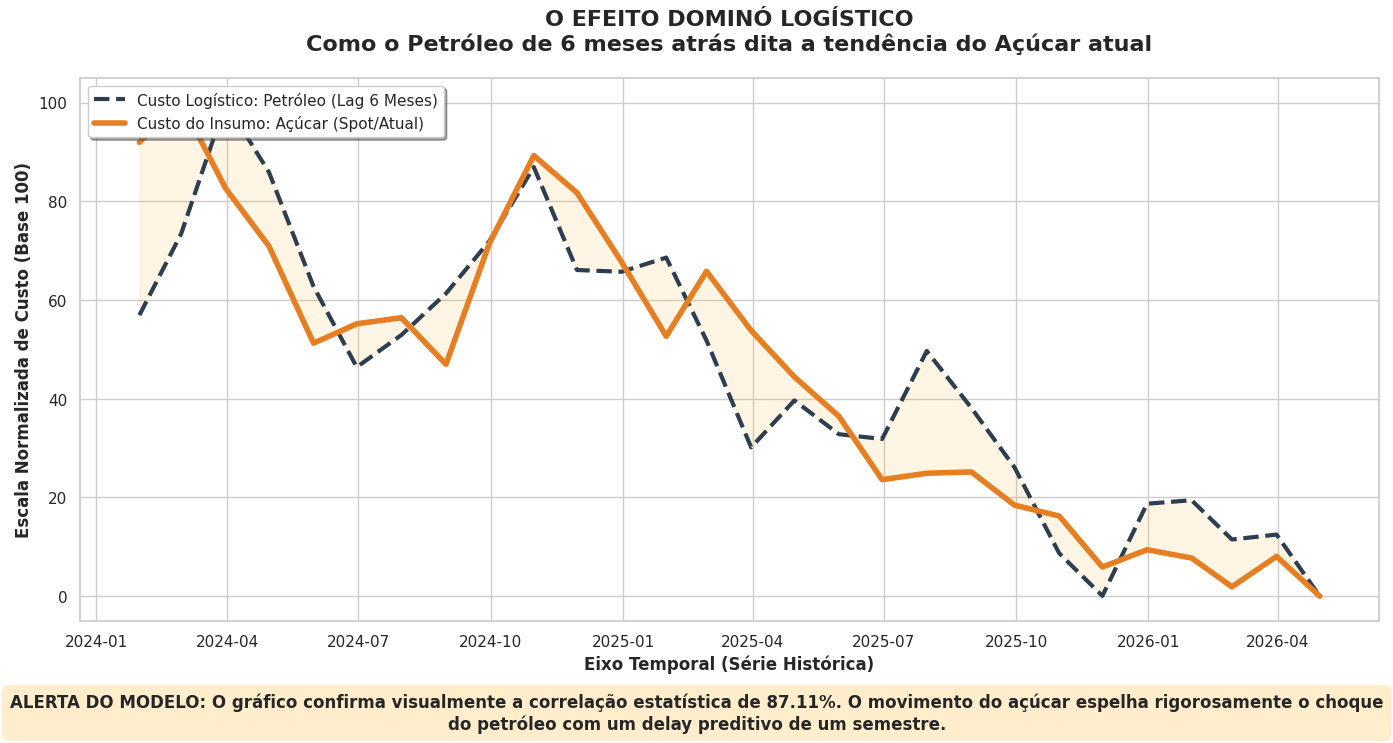


Renderização do Cenário concluída com sucesso!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# INGESTÃO DE DADOS
file_path = "dataset_projeto_pascoa.xlsx"

if not os.path.exists(file_path):
    print(f"Erro: O arquivo '{file_path}' não foi encontrado no diretório atual.")
else:
    # Leitura do dataset e conversão do eixo temporal para o tipo datetime
    df = pd.read_excel(file_path)
    df['Data'] = pd.to_datetime(df['Data'])
    df = df.sort_values('Data')

    # NORMALIZAÇÃO ESPACIAL
    # Como o Petróleo é cotado em Dólares/Barril e o Açúcar em Dólares/Libra-peso,
    # aplicamos o MinMaxScaler. Isso projeta ambas as séries temporais em um vetor
    # dimensional de 0 a 100, permitindo a comparação visual de suas tendências.
    # ------------------------------------------------------------------------------
    scaler = MinMaxScaler(feature_range=(0, 100))

    # Aplicação da normalização focando na variável defasada (Lag 6M) para o Petróleo
    df['Petroleo_Norm'] = scaler.fit_transform(df[['Petroleo_6M_Atras']])
    df['Acucar_Norm'] = scaler.fit_transform(df[['Acucar']])


    # Construção do gráfico de Séries Temporais Sobrepostas.
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Série Indutora: Petróleo (Variável Preditiva)
    plt.plot(df['Data'], df['Petroleo_Norm'], label='Custo Logístico: Petróleo (Lag 6 Meses)',
             color='#2c3e50', linewidth=3, linestyle='--')

    # Série Alvo: Açúcar (Variável Dependente Spot)
    plt.plot(df['Data'], df['Acucar_Norm'], label='Custo do Insumo: Açúcar (Spot/Atual)',
             color='#e67e22', linewidth=4)

    # Evidencia a covariância e o GAP de repasse
    plt.fill_between(df['Data'], df['Petroleo_Norm'], df['Acucar_Norm'], color='orange', alpha=0.1)

    # Formatação
    plt.title('O EFEITO DOMINÓ LOGÍSTICO\nComo o Petróleo de 6 meses atrás dita a tendência do Açúcar atual',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Eixo Temporal (Série Histórica)', fontsize=12, fontweight='bold')
    plt.ylabel('Escala Normalizada de Custo (Base 100)', fontsize=12, fontweight='bold')
    plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)


    # GERAÇÃO DE INSIGHT
    insight = ("ALERTA DO MODELO: O gráfico confirma visualmente a correlação estatística de 87.11%. "
               "O movimento do açúcar espelha rigorosamente o choque do petróleo com um delay preditivo de um semestre.")

    plt.figtext(0.5, -0.05, insight, wrap=True, horizontalalignment='center',
                fontsize=12, fontweight='bold', bbox={'facecolor':'orange', 'alpha':0.2, 'pad':8, 'boxstyle':'round,pad=0.5'})

    plt.tight_layout()
    plt.show()

    print("\nRenderização do Cenário concluída com sucesso!")

## **Cenário - A Pinça Macroeconômica (Dólar X Cenário Economico)**

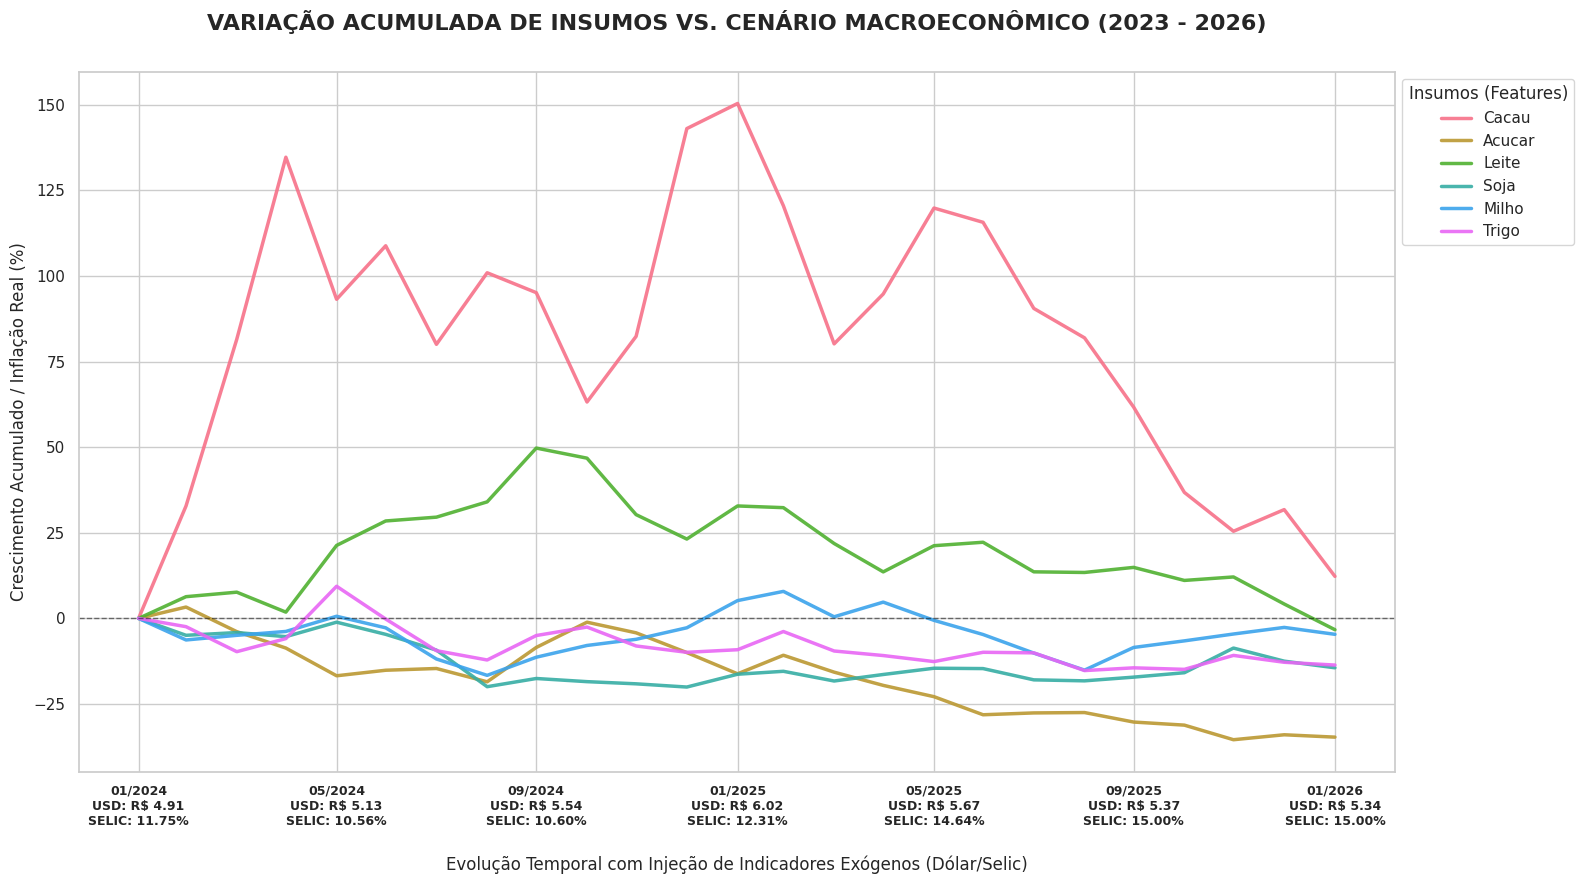

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# INGESTÃO DE DADOS
# Estabelecemos uma janela de observação focada no período de maior estresse
# pós-pandêmico (Jan/2023 a Fev/2026).

df = pd.read_excel("dataset_projeto_pascoa.xlsx")
df['Data'] = pd.to_datetime(df['Data'])
df_plot = df[(df['Data'] >= '2023-01-01') & (df['Data'] <= '2026-02-01')].copy()

# NORMALIZAÇÃO POR BASELINE (VARIAÇÃO ACUMULADA)
alimentos = ['Cacau', 'Acucar', 'Leite', 'Soja', 'Milho', 'Trigo']

for item in alimentos:
    valor_inicial = df_plot[item].iloc[0]
    df_plot[f'{item}_Var'] = ((df_plot[item] / valor_inicial) - 1) * 100


# RENDERIZAÇÃO DO GRÁFICO
plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")

# Paleta de cores para diferenciação categórica
cores = sns.color_palette("husl", len(alimentos))

# Plotagem iterativa de múltiplas séries
for i, item in enumerate(alimentos):
    plt.plot(df_plot['Data'], df_plot[f'{item}_Var'],
             label=item, linewidth=2.5, color=cores[i], alpha=0.9)

# ENRIQUECIMENTO DO EIXO X COM VARIÁVEIS MACROECONÔMICAS
# Overriding dos labels X para injetar contexto (Selic/Dólar).
indices_eixo = range(0, len(df_plot), 4) # Sampling a cada quadrimestre
datas_sel = df_plot['Data'].iloc[indices_eixo]
valores_dolar = df_plot['Dolar'].iloc[indices_eixo].apply(lambda x: f'R$ {x:.2f}')
valores_selic = df_plot['Selic'].iloc[indices_eixo].apply(lambda x: f'{x:.2f}%')

# Concatenando strings para criar uma matriz informativa multi-linha no eixo
labels_completos = [
    f"{d.strftime('%m/%Y')}\nUSD: {v}\nSELIC: {s}"
    for d, v, s in zip(datas_sel, valores_dolar, valores_selic)
]

plt.xticks(datas_sel, labels_completos, fontsize=9, fontweight='bold')

# Estética e Títulos
plt.title('VARIAÇÃO ACUMULADA DE INSUMOS VS. CENÁRIO MACROECONÔMICO (2023 - 2026)',
          fontsize=16, fontweight='bold', pad=30)
plt.ylabel('Crescimento Acumulado / Inflação Real (%)', fontsize=12)
plt.xlabel('Evolução Temporal com Injeção de Indicadores Exógenos (Dólar/Selic)', fontsize=12, labelpad=20)

# Linha de Referência Teórica (Baseline Zero)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.legend(title="Insumos (Features)", loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.tight_layout()
plt.show()

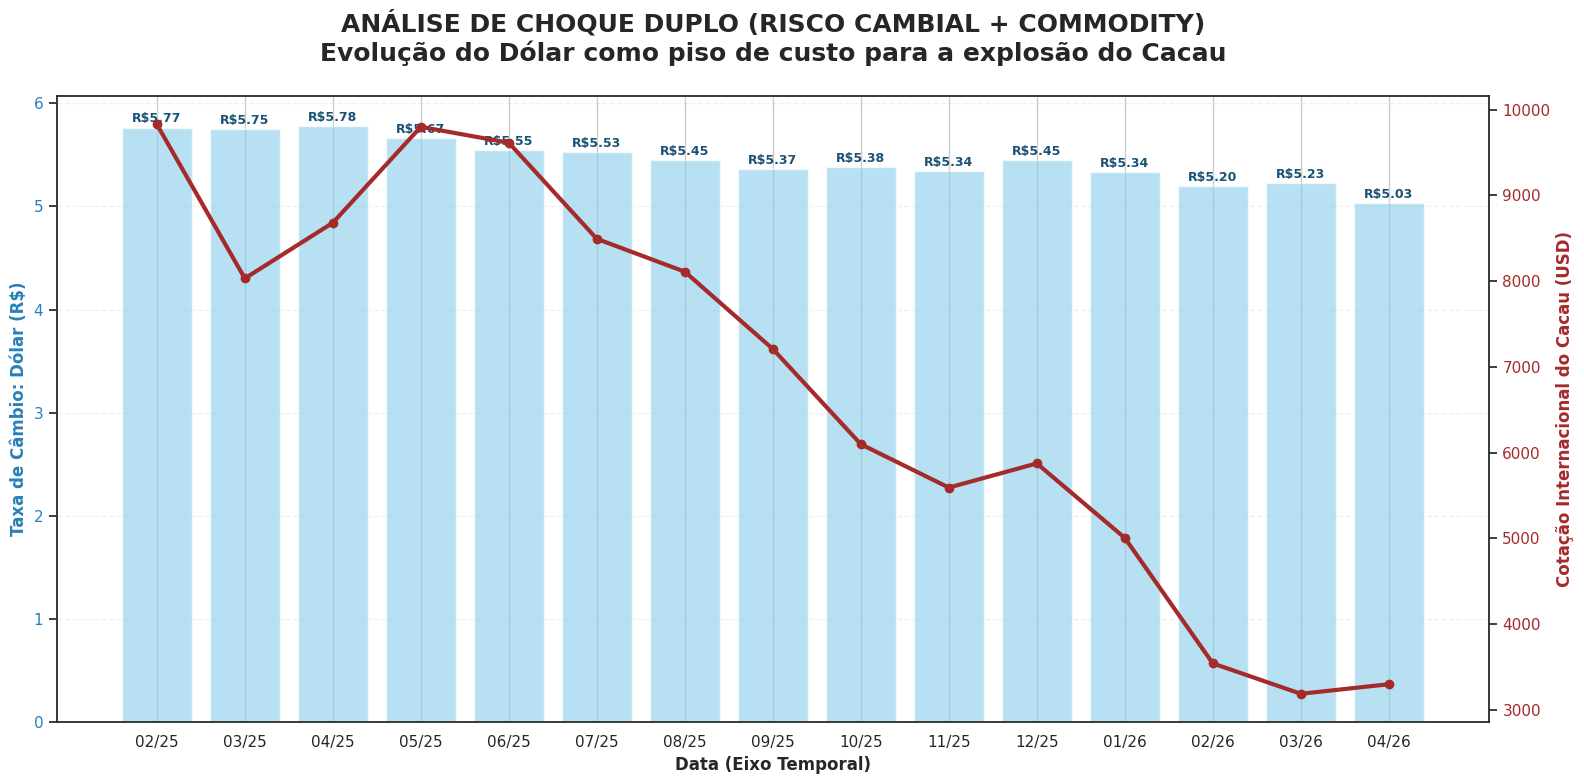

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# INGESTÃO DE DADOS

arquivos = glob.glob("*pascoa*")
file_path = arquivos[0]

# Validação do formato do arquivo ingerido
if file_path.endswith('.csv'):
    df = pd.read_csv(file_path)
else:
    df = pd.read_excel(file_path)

# Conversão temporal e aplicação do Time, limitamos aos últimos 15 meses
df['Data'] = pd.to_datetime(df['Data'])
df = df.sort_values('Data').tail(15)


# SÉRIES TEMPORAIS COM EIXO DUPLO
fig, ax1 = plt.subplots(figsize=(16, 8))
sns.set_theme(style="white")

# --- EIXO PRIMÁRIO (Y1): VARIÁVEL DE CONTEXTO MACRO (DÓLAR) ---
# Usamos o gráfico de barras para representar a "Baseline de Custo".
ax1.set_xlabel('Data (Eixo Temporal)', fontweight='bold')
ax1.set_ylabel('Taxa de Câmbio: Dólar (R$)', color='#2980b9', fontsize=12, fontweight='bold')
bars = ax1.bar(df['Data'].dt.strftime('%m/%y'), df['Dolar'], color='skyblue', alpha=0.6, label='Dólar (R$)')
ax1.tick_params(axis='y', labelcolor='#2980b9')

# Injeção dosRótulos de Dados diretamente nas barras para facilitar a leitura
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'R${height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a5276')

# --- EIXO SECUNDÁRIO (Y2): VARIÁVEL DE CHOQUE DE OFERTA (CACAU) ---
# Usamos o gráfico de linhas sobreposto para evidenciar a tendência.
ax2 = ax1.twinx() # Instanciação do segundo eixo Y compartilhando o eixo X
ax2.set_ylabel('Cotação Internacional do Cacau (USD)', color='brown', fontsize=12, fontweight='bold')
line = ax2.plot(df['Data'].dt.strftime('%m/%y'), df['Cacau'], color='brown', marker='o', linewidth=3, label='Custo Spot do Cacau')
ax2.tick_params(axis='y', labelcolor='brown')

# ESTÉTICA E RENDERIZAÇÃO
plt.title('ANÁLISE DE CHOQUE DUPLO (RISCO CAMBIAL + COMMODITY)\nEvolução do Dólar como piso de custo para a explosão do Cacau',
          fontsize=18, fontweight='bold', pad=25)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

fig.tight_layout()
plt.show()

## **Cenário - Cenário Macro: "Custo Brasil" (Dólar, Selic e Inflação)**

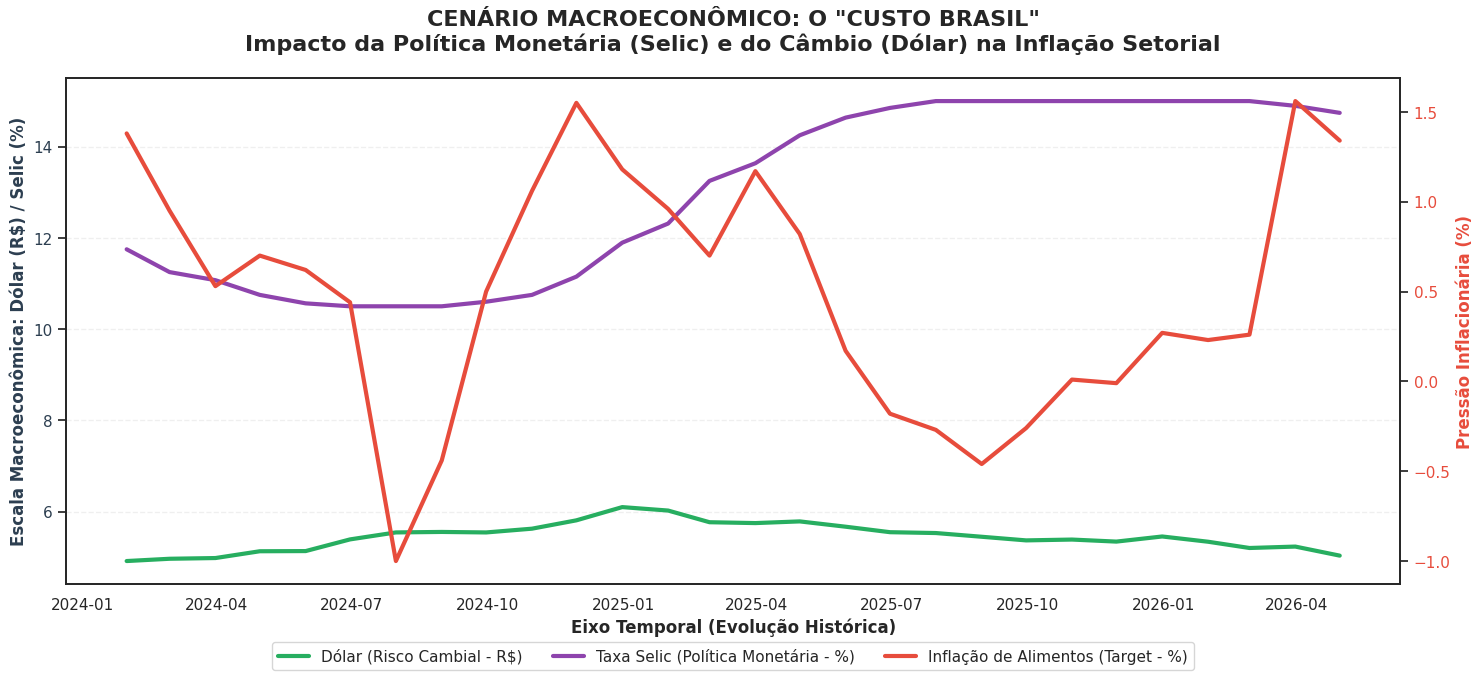

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Busca dinâmica pelo dataset na raiz do projeto e tipagem do eixo cronológico.
arquivos = glob.glob("*pascoa*")
if not arquivos:
    print("Por favor, faça o upload do arquivo do dataset (Excel ou CSV).")
else:
    file_path = arquivos[0]
    df = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    df['Data'] = pd.to_datetime(df['Data'])
    df = df.sort_values('Data')


    # EIXOS MÚLTIPLOS (DUAL-AXIS)
    fig, ax1 = plt.subplots(figsize=(15, 7))
    sns.set_theme(style="white")

    # --- EIXO PRIMÁRIO (Esquerda): Indicadores Macroeconômicos (Variáveis Exógenas) ---
    # Linha Verde: Dólar (Risco Cambial de Importação)
    linha_dolar = ax1.plot(df['Data'], df['Dolar'], color='#27ae60', linewidth=3, label='Dólar (Risco Cambial - R$)')

    # Linha Roxa: Selic (Custo de Capital / Freio Monetário)
    linha_selic = ax1.plot(df['Data'], df['Selic'], color='#8e44ad', linewidth=3, label='Taxa Selic (Política Monetária - %)')

    ax1.set_xlabel('Eixo Temporal (Evolução Histórica)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Escala Macroeconômica: Dólar (R$) / Selic (%)', color='#2c3e50', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2c3e50')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- EIXO SECUNDÁRIO (Direita): Variável Alvo / Target (Inflação) ---
    # A função twinx() espelha o eixo X, permitindo plotar a inflação em sua
    # própria escala percentual sem que as linhas primárias sejam "esmagadas"
    ax2 = ax1.twinx()

    # Linha Vermelha: Inflação (Impacto final no consumidor)
    linha_inflacao = ax2.plot(df['Data'], df['Inflacao_Alimentos'], color='#e74c3c', linewidth=3, linestyle='-', label='Inflação de Alimentos (Target - %)')

    ax2.set_ylabel('Pressão Inflacionária (%)', color='#e74c3c', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#e74c3c')


    # ESTÉTICA, TITULAÇÃO E CONSOLIDAÇÃO DE LEGENDAS
    plt.title('CENÁRIO MACROECONÔMICO: O "CUSTO BRASIL"\nImpacto da Política Monetária (Selic) e do Câmbio (Dólar) na Inflação Setorial',
              fontsize=16, fontweight='bold', pad=20)

    # Consolidação das linhas de ambos os eixos em um único contêiner de legenda
    linhas = linha_dolar + linha_selic + linha_inflacao
    labels = [l.get_label() for l in linhas]
    ax1.legend(linhas, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=True, fontsize=11)

    fig.tight_layout()
    plt.show()


## **Cenário - Correlações Inversas e Substiuição de ingredientes**

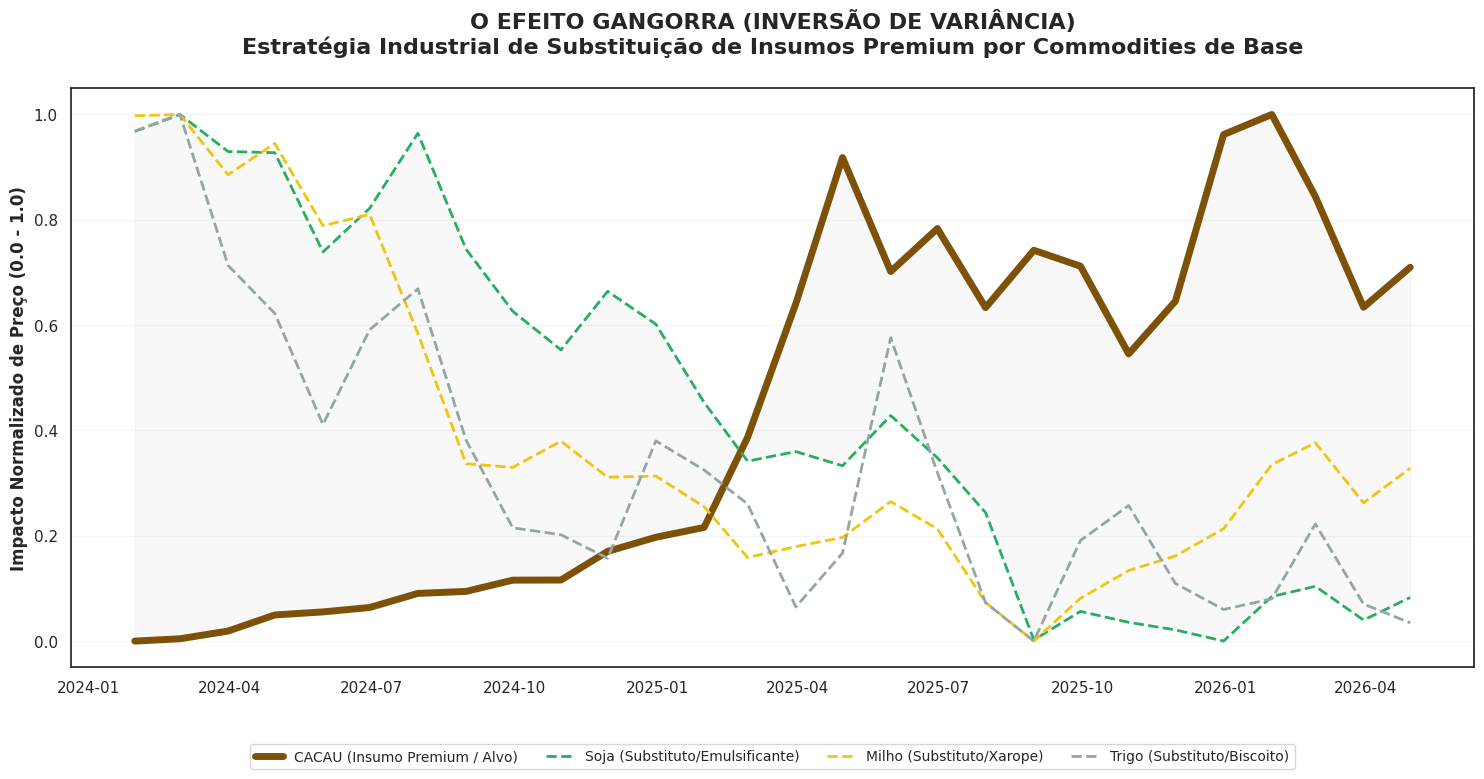

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os
import glob

# INGESTÃO DE DADOS
arquivos = glob.glob("*pascoa*")
file_path = arquivos[0]
df = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
df['Data'] = pd.to_datetime(df['Data'])
df = df.sort_values('Data')

# NORMALIZAÇÃO
scaler = MinMaxScaler()
cols_lag = ['Cacau_12M_Atras', 'Soja_12M_Atras', 'Milho_12M_Atras', 'Trigo_12M_Atras']
df[[c + '_Norm' for c in cols_lag]] = scaler.fit_transform(df[cols_lag])


#  PLOTAGEM DE SÉRIES DIVERGENTES
plt.figure(figsize=(15, 8))
sns.set_theme(style="white")

# --- O DRIVER DE CUSTO (Target Principal) ---
# Linha espessa para destacar o vetor de pressão primária.
plt.plot(df['Data'], df['Cacau_12M_Atras_Norm'], color='#7e5109', linewidth=5, label='CACAU (Insumo Premium / Alvo)')

# --- VARIÁVEIS DE COMPENSAÇÃO (Substitutos de Formulação) ---
# Linhas tracejadas para representar a matriz de amortecimento de custo.
plt.plot(df['Data'], df['Soja_12M_Atras_Norm'], color='#27ae60', linewidth=2, linestyle='--', label='Soja (Substituto/Emulsificante)')
plt.plot(df['Data'], df['Milho_12M_Atras_Norm'], color='#f1c40f', linewidth=2, linestyle='--', label='Milho (Substituto/Xarope)')
plt.plot(df['Data'], df['Trigo_12M_Atras_Norm'], color='#95a5a6', linewidth=2, linestyle='--', label='Trigo (Substituto/Biscoito)')

# Estética, Titulação e Configuração Espacial
plt.title('O EFEITO GANGORRA (INVERSÃO DE VARIÂNCIA)\nEstratégia Industrial de Substituição de Insumos Premium por Commodities de Base',
          fontsize=16, fontweight='bold', pad=25)

plt.ylabel('Impacto Normalizado de Preço (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=True, fontsize=10)

# Shading: O sombreamento entre Cacau e Soja demarca visualmente a área de "Trade-off" (GAP)
plt.fill_between(df['Data'], df['Cacau_12M_Atras_Norm'], df['Soja_12M_Atras_Norm'], color='gray', alpha=0.05)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()



## **Cenário - Período de Substiuição de Insumos**

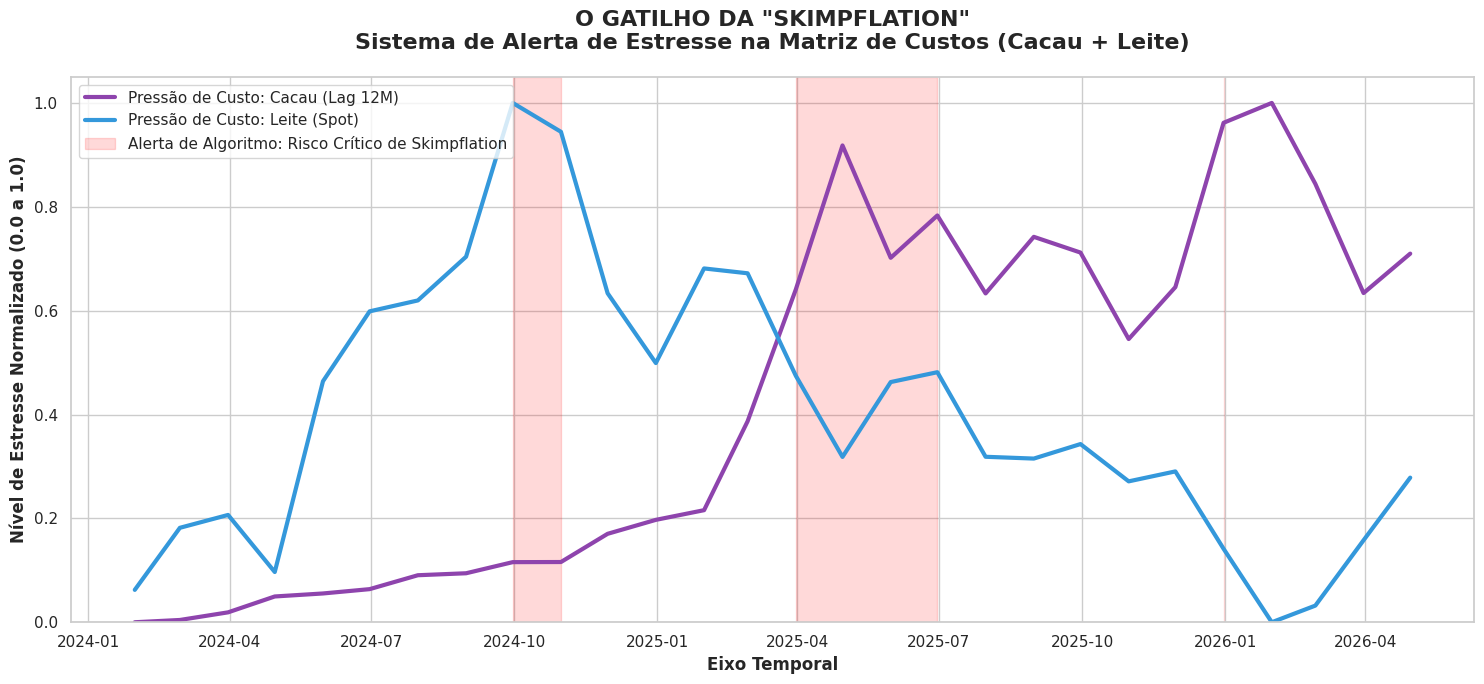

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import glob

# INGESTÃO DE DADOS
arquivos = glob.glob("*pascoa*")
if not arquivos:
    print("Erro: Arquivo do dataset não encontrado no diretório ativo.")
else:
    file_path = arquivos[0]
    df = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    df['Data'] = pd.to_datetime(df['Data'])
    df = df.sort_values('Data')

    # NORMALIZAÇÃO DIMENSIONAL
    scaler = MinMaxScaler()
    df[['Cacau_Norm', 'Leite_Norm']] = scaler.fit_transform(df[['Cacau_12M_Atras', 'Leite']])

    # DETECÇÃO DE ANOMALIA E THRESHOLDING
    df['Pressao_Dupla'] = df['Cacau_Norm'] + df['Leite_Norm']
    limite_critico = df['Pressao_Dupla'].quantile(0.75)


    # VISUALIZAÇÃO PRESCRITIVA
    plt.figure(figsize=(15, 7))
    sns.set_theme(style="whitegrid")

    # Plotagem dos vetores de custo isolados
    plt.plot(df['Data'], df['Cacau_Norm'], label='Pressão de Custo: Cacau (Lag 12M)', color='#8e44ad', linewidth=3)
    plt.plot(df['Data'], df['Leite_Norm'], label='Pressão de Custo: Leite (Spot)', color='#3498db', linewidth=3)

    # Shading Condicional: Renderiza a "Zona de Risco" (área vermelha)
    plt.fill_between(df['Data'], 0, 1.05, where=(df['Pressao_Dupla'] > limite_critico),
                     color='red', alpha=0.15, label='Alerta de Algoritmo: Risco Crítico de Skimpflation')

    # Estética e Titulação
    plt.title('O GATILHO DA "SKIMPFLATION"\nSistema de Alerta de Estresse na Matriz de Custos (Cacau + Leite)',
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Nível de Estresse Normalizado (0.0 a 1.0)', fontsize=12, fontweight='bold')
    plt.xlabel('Eixo Temporal', fontsize=12, fontweight='bold')

    plt.legend(loc='upper left', frameon=True, fontsize=11)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# ***Base de preços Maiores marcas (web scraping - Mercado livre) / Codigo do web scraping no [GitHub](https://github.com/ViniciusPaula140/Analise-de-chocolate)***

In [ ]:
import urllib.request
import pandas as pd
import os
import time

print("Baixando o arquivo do GitHub para a pasta do Colab...")
# MAPEAMENTO DA NUVEM (URL RAW)
url = "https://raw.githubusercontent.com/ViniciusPaula140/Analise-de-chocolate/main/base_completa_chocolates.xlsx"

# O nome que o arquivo terá no sistema de arquivos temporário do Google Colab
nome_arquivo = "base_completa_chocolates.xlsx"

# DOWNLOAD FÍSICO DO ARQUIVO
urllib.request.urlretrieve(url, nome_arquivo)


# TRAVA DE SINCRONIZAÇÃO (Prevenção de erro no "Run All")
# Força o Python a esperar o Colab terminar de escrever o arquivo no disco
tentativas = 0
while not os.path.exists(nome_arquivo) and tentativas < 10:
    time.sleep(1)
    tentativas += 1

# Se após 10 segundos o arquivo não aparecer, o código aborta para evitar um erro em cascata
if not os.path.exists(nome_arquivo):
    raise FileNotFoundError(f"ERRO CRÍTICO: Falha de rede ao baixar '{nome_arquivo}'. Pare o código e verifique a internet.")

print(f"Arquivo '{nome_arquivo}' baixado e sincronizado com o disco local!")


# LEITURA E VALIDAÇÃO DOS DADOS DO CONSUMIDOR
df_scraping = pd.read_excel(nome_arquivo)

# Mostra o resultado para confirmar que a ingestão foi um sucesso
display(df_scraping.head())

Baixando o arquivo do GitHub para a pasta do Colab...
Arquivo 'base_completa_chocolates.xlsx' baixado e sincronizado com o disco local!


,Marca,Produto,Preco_Hoje,Fonte
0,Lacta,Ovo De Páscoa Lacta Tripla Camada Laka Caramel...,159.90,Mercado Livre
1,Lacta,Ovo de Páscoa Lacta Tripla Camada Laka Caramel...,159.90,Mercado Livre
2,Lacta,Ovo Páscoa Ao Leite Recheio Avelã Tripla Camad...,180.00,Mercado Livre
3,Lacta,Ovo de Páscoa Sonho de Valsa Lacta 357g,160.00,Mercado Livre
4,Lacta,Ovo de Páscoa Lacta Tripla Camada Oreo 320g,239.99,Mercado Livre


# **Análise Preditiva**

**RANDOM FOREST**

Aguardando a gravação completa do arquivo Excel (Proteção contra Desconexão)
Arquivo validado com sucesso! Iniciando Inteligência Artificial...
R² Final: 0.8412
MAE Final: 0.2030


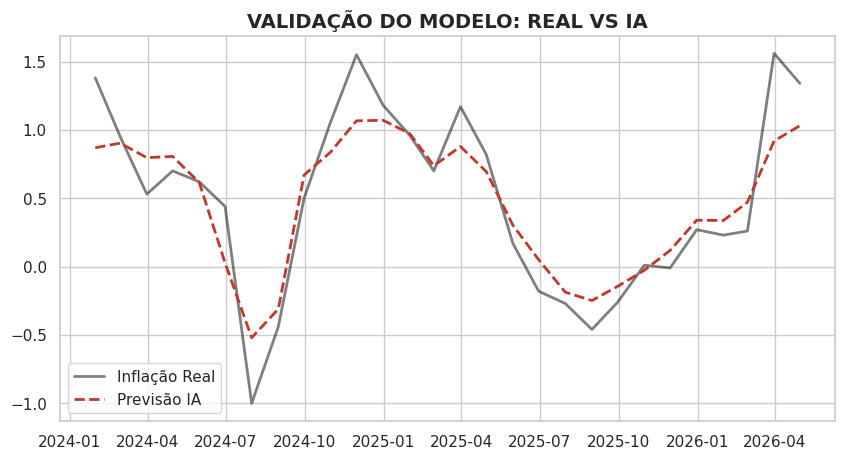


         VEREDITO DE MERCADO E DIRETRIZES DE COMPRA         
ALERTA: Projeção de alta de 1.0%. Antecipe estoques para evitar inflação.


In [ ]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

arquivo_macro = "dataset_projeto_pascoa.xlsx"

print("Aguardando a gravação completa do arquivo Excel (Proteção contra Desconexão)")

arquivo_pronto = False
for tentativa in range(15):
    if os.path.exists(arquivo_macro):
        try:
            df_teste = pd.read_excel(arquivo_macro, nrows=1)
            arquivo_pronto = True
            break
        except Exception:
            pass

    time.sleep(2)

if not arquivo_pronto:
    raise RuntimeError(f"ERRO CRÍTICO: O arquivo '{arquivo_macro}' não terminou de ser gravado a tempo.")

print("Arquivo validado com sucesso! Iniciando Inteligência Artificial...")

# CARREGAMENTO SEGURO
df_macro = pd.read_excel(arquivo_macro)
df_macro['Data'] = pd.to_datetime(df_macro['Data'])
df_macro = df_macro.sort_values('Data').dropna()

# DEFINIÇÃO ESTRATÉGICA
features_ia = ['Cacau_12M_Atras', 'Petroleo_6M_Atras', 'Dolar_6M_Atras', 'Selic', 'Leite']
target_ia = 'Inflacao_Alimentos'

X = df_macro[features_ia]
y = df_macro[target_ia]

# TREINAMENTO
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
modelo_rf.fit(X, y)

# AVALIAÇÃO DE PERFORMANCE
previsoes = modelo_rf.predict(X)
print(f"R² Final: {r2_score(y, previsoes):.4f}")
print(f"MAE Final: {mean_absolute_error(y, previsoes):.4f}")

# VISUALIZAÇÃO DE VALIDAÇÃO
plt.figure(figsize=(10, 5))
plt.plot(df_macro['Data'], y, label='Inflação Real', color='black', alpha=0.5, linewidth=2)
plt.plot(df_macro['Data'], previsoes, label='Previsão IA', color='#c0392b', linestyle='--', linewidth=2)
plt.title('VALIDAÇÃO DO MODELO: REAL VS IA', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# LÓGICA DE NEGÓCIO (Tradução do Veredito)
taxa_projetada = previsoes[-1]

print("\n" + "="*60)
print("VEREDITO DE MERCADO E DIRETRIZES DE COMPRA".center(60))
print("="*60)

if taxa_projetada > 0.3:
    recomendacao = f"ALERTA: Projeção de alta de {taxa_projetada:.1f}%. Antecipe estoques para evitar inflação."
elif taxa_projetada < -0.3:
    recomendacao = f"OPORTUNIDADE: Projeção de queda de {abs(taxa_projetada):.1f}%. Aguarde janela de compra."
else:
    recomendacao = f"ESTABILIDADE: Projeção de {taxa_projetada:.1f}%. Cenário neutro, foque na gestão de fluxo de caixa."

print(recomendacao)
print("="*60)

# **Previsão de preço das marcas para 2027**


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# VERIFICAÇÃO DE SEGURANÇA
if 'taxa_projetada' not in globals():
    raise NameError("A 'taxa_projetada' não foi encontrada. Rode a célula da IA (Módulo 5/6) primeiro!")

arquivo_scraping = "base_completa_chocolates.xlsx"
if not os.path.exists(arquivo_scraping):
    raise FileNotFoundError("O ficheiro de chocolates não foi encontrado. Certifique-se de rodar o Scraping.")

# CARREGAMENTO DOS DADOS DO VAREJO
df_varejo = pd.read_excel(arquivo_scraping)

# DETECÇÃO AUTOMÁTICA DE COLUNAS
colunas_excel = df_varejo.columns.tolist()

coluna_preco = None
coluna_produto = None
coluna_marca = None

# Busca inteligente pelo nome exato das colunas no seu arquivo
for col in colunas_excel:
    nome_limpo = col.lower().strip()
    if 'preç' in nome_limpo or 'prec' in nome_limpo or 'valor' in nome_limpo or 'r$' in nome_limpo:
        coluna_preco = col
    elif 'prod' in nome_limpo or 'nome' in nome_limpo or 'descri' in nome_limpo or 'item' in nome_limpo:
        coluna_produto = col
    elif 'marc' in nome_limpo or 'fabric' in nome_limpo or 'brand' in nome_limpo:
        coluna_marca = col


if not coluna_preco or not coluna_produto or not coluna_marca:
    raise KeyError(f"Não consegui identificar as colunas! Suas colunas reais são: {colunas_excel}")

print(f"Colunas detectadas: Marca='{coluna_marca}', Produto='{coluna_produto}', Preço='{coluna_preco}'")

# Tratamento de dados: Garante que o preço seja tratado como número
if df_varejo[coluna_preco].dtype == 'object':
    df_varejo[coluna_preco] = pd.to_numeric(df_varejo[coluna_preco].astype(str).str.replace('R$', '').str.replace(',', '.').str.strip(), errors='coerce')

# O MOTOR DE CÁLCULO PREDITIVO
df_varejo['Preco_2027'] = df_varejo[coluna_preco] * (1 + (taxa_projetada / 100))

# Extrai uma lista limpa e em ordem alfabética
lista_marcas = sorted(df_varejo[coluna_marca].dropna().unique().tolist())

# CRIAÇÃO DOS ELEMENTOS VISUAIS (WIDGETS)
dropdown_marca = widgets.Dropdown(
    options=['Escolha uma marca...'] + lista_marcas,
    value='Escolha uma marca...',
    description='Marca:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

output_area = widgets.Output()

# A FUNÇÃO DE INTERATIVIDADE
def atualizar_dashboard(change):
    marca_selecionada = change.new

    with output_area:
        clear_output(wait=True)

        if marca_selecionada == 'Escolha uma marca...':
            return

        print(f"\n MARCA SELECIONADA: {marca_selecionada.upper()}")
        print(f" Taxa de Inflação Aplicada pela IA: {taxa_projetada:.2f}%")
        print("=" * 70)

        df_filtrado = df_varejo[df_varejo[coluna_marca] == marca_selecionada]

        for index, row in df_filtrado.iterrows():
            nome = row[coluna_produto]
            preco_atual = row[coluna_preco]
            preco_2027 = row['Preco_2027']

            # Pula produtos que vieram sem preço da internet
            if pd.isna(preco_atual):
                continue

            print(f"-> {nome}")
            print(f"   ↳ Preço 2026: R$ {preco_atual:.2f}  |  Previsão 2027: R$ {preco_2027:.2f}\n")

# Conecta o botão à função
dropdown_marca.observe(atualizar_dashboard, names='value')

# Exibe o painel
display(dropdown_marca, output_area)

Colunas detectadas: Marca='Marca', Produto='Produto', Preço='Preco_Hoje'


Dropdown(description='Marca:', layout=Layout(width='400px'), options=('Escolha uma marca...', 'Ferrero', 'Garo…

Output()